In [6]:
#load libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv('/content/tesla_deliveries_dataset_2015_2025.csv')

print(df.head())

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [9]:
# data info
print(df.shape)

print(df.columns)

print(df.info())

(2640, 12)
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-nul

In [10]:
# checking missing values
print(df.isnull().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [11]:
# remove duplicates
df.drop_duplicates(inplace=True)

print(df.shape)

(2640, 12)


In [12]:
#statistical summmary
print(df.describe())

              Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640.000000           2640.000000       2640.000000   
mean   2020.000000     6.500000           9922.199621      10655.847348   
std       3.162877     3.452707           3935.950093       4260.600858   
min    2015.000000     1.000000             48.000000         50.000000   
25%    2017.000000     3.750000           7292.000000       7828.250000   
50%    2020.000000     6.500000           9857.000000      10546.500000   
75%    2023.000000     9.250000          12510.250000      13469.000000   
max    2025.000000    12.000000          25704.000000      28939.000000   

       Avg_Price_USD  Battery_Capacity_kWh     Range_km  CO2_Saved_tons  \
count    2640.000000           2640.000000  2640.000000     2640.000000   
mean    84907.340330             87.059470   500.257576      744.076989   
std     20123.258036             20.836265   120.868549      353.221224   
min     50003.700000    

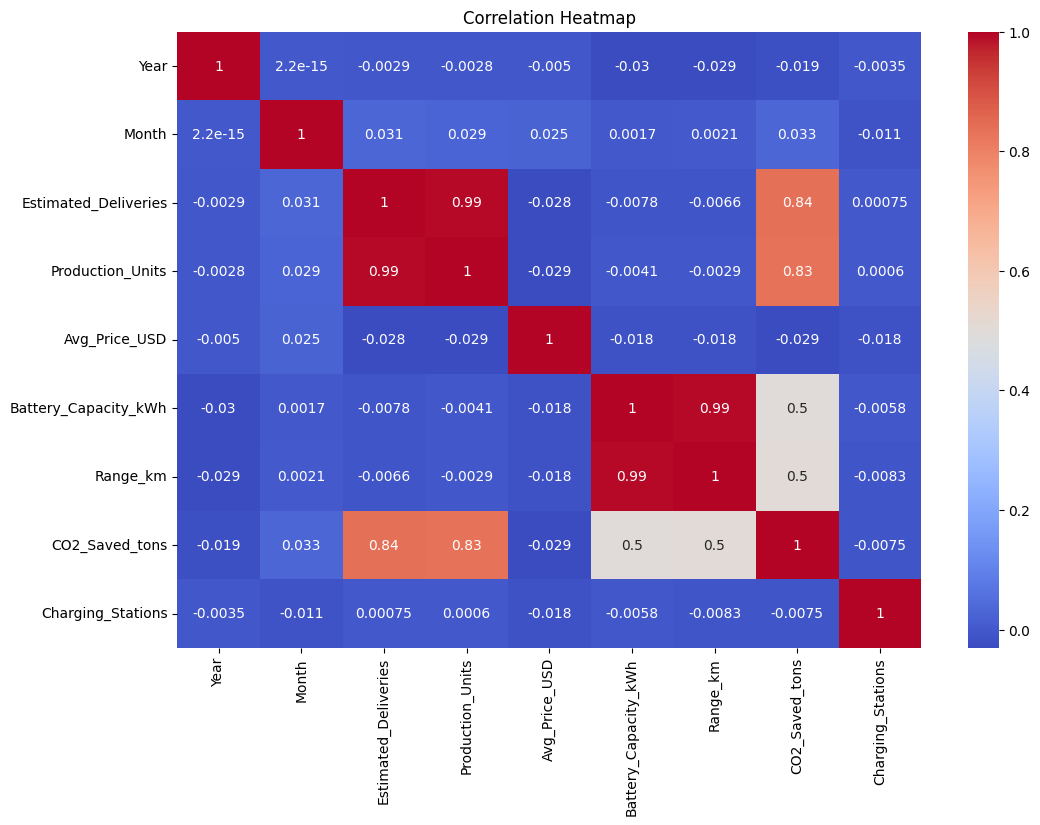

In [13]:
# heatmap
plt.figure(figsize=(12,8))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

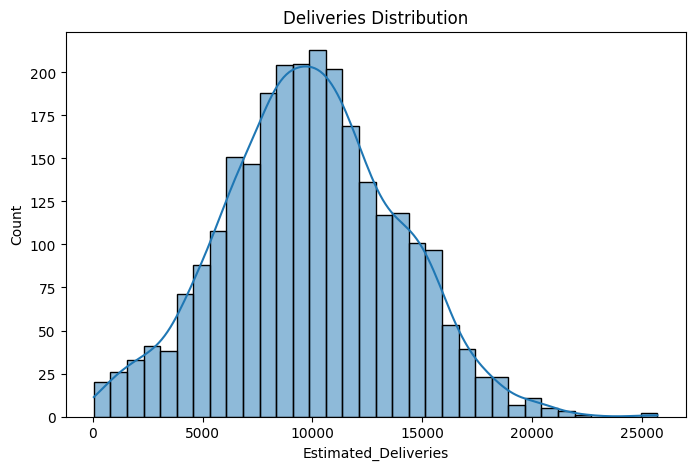

In [17]:
# Distribution plot
plt.figure(figsize=(8,5))

sns.histplot(df['Estimated_Deliveries'],
             kde=True)

plt.title("Deliveries Distribution")

plt.show()

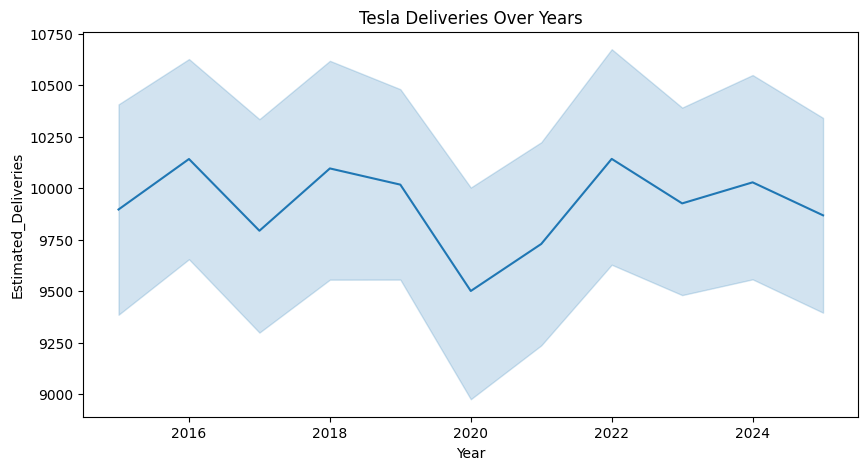

In [21]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x='Year',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Tesla Deliveries Over Years")

plt.show()

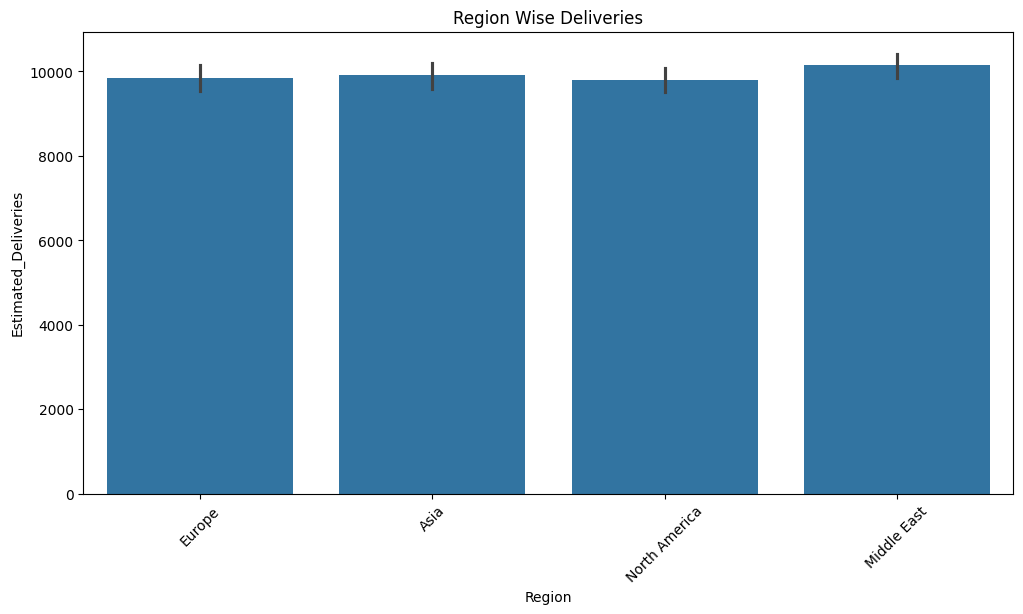

In [24]:
# Region over deliveries
plt.figure(figsize=(12,6))

sns.barplot(
    x='Region',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Region Wise Deliveries")

plt.xticks(rotation=45)

plt.show()

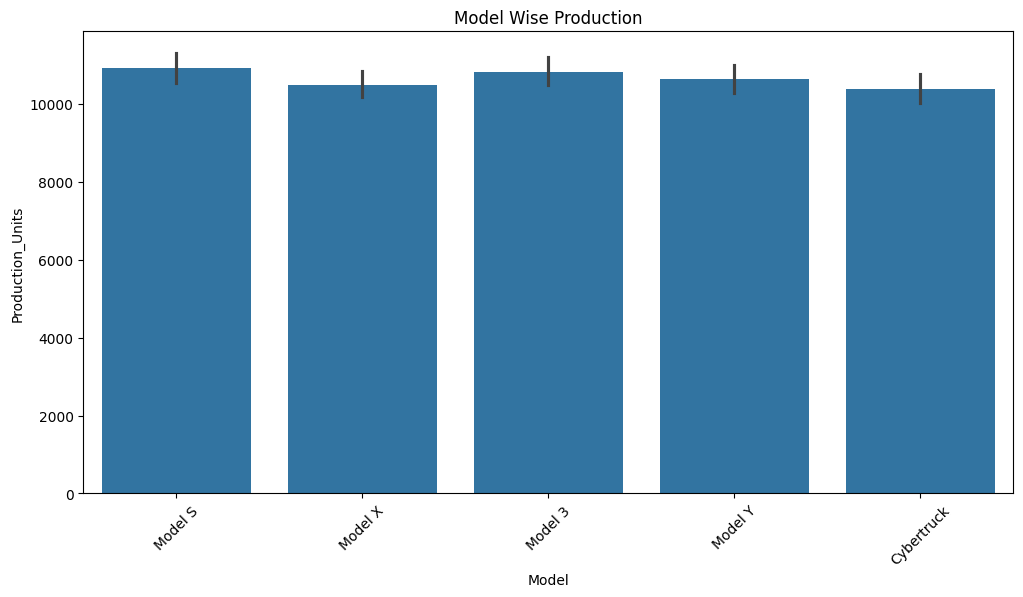

In [26]:
#Model wise prediction
plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='Production_Units',
    data=df
)

plt.title("Model Wise Production")

plt.xticks(rotation=45)

plt.show()

# Feature Enginneering

In [55]:
# Feature Engineering

df['Price_Per_km'] = (
    df['Avg_Price_USD'] /
    (df['Range_km'] + 1)
)

print(df.head())

   Year  Month  Region  Model  Estimated_Deliveries  Production_Units  \
0  2023      5       1      2                 17646             17922   
1  2015      2       0      3                  3797              4164   
2  2019      1       3      3                  8411              9189   
3  2021      2       3      1                  6555              7311   
4  2016     12       2      4                 12374             13537   

   Avg_Price_USD  Battery_Capacity_kWh  Range_km  CO2_Saved_tons  Source_Type  \
0       92874.27                   120       704         1863.42            1   
1       62205.65                    75       438          249.46            2   
2      117887.32                    82       480          605.59            1   
3       89294.91                   120       712          700.07            2   
4      114846.78                   120       661         1226.88            0   

   Charging_Stations  production_efficiency  price_per_km  Price_Per_km  


In [56]:
#Encode categorical values
label_encoder = LabelEncoder()

categorical_cols = ['Region', 'Model', 'Source_Type']

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

In [78]:
X = df[
    [
        'Year',
        'Region',
        'Model',
        'Production_Units',
        'Avg_Price_USD',
        'Range_km',
        'Battery_Capacity_kWh'
    ]
]

y = df['Estimated_Deliveries']

In [79]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# LINEAR REGRESSION

In [80]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

In [81]:
print("LINEAR REGRESSION RESULTS")

print("MAE:",
      mean_absolute_error(y_test, linear_pred))

print("MSE:",
      mean_squared_error(y_test, linear_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, linear_pred)))

print("R2 Score:",
      r2_score(y_test, linear_pred))

LINEAR REGRESSION RESULTS
MAE: 339.9714031989576
MSE: 174124.60837760995
RMSE: 417.2824084209757
R2 Score: 0.9883187144368623


# DECISION TREE REGRESSOR

In [82]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [83]:
print("DECISION TREE RESULTS")

print("MAE:",
      mean_absolute_error(y_test, dt_pred))

print("MSE:",
      mean_squared_error(y_test, dt_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, dt_pred)))

print("R2 Score:",
      r2_score(y_test, dt_pred))

DECISION TREE RESULTS
MAE: 494.58522727272725
MSE: 415563.8125
RMSE: 644.6423911751383
R2 Score: 0.9721215765608986


# RANDOM FOREST REGRESSOR

In [85]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [86]:
print("RANDOM FOREST RESULTS")

print("MAE:",
      mean_absolute_error(y_test, rf_pred))

print("MSE:",
      mean_squared_error(y_test, rf_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 Score:",
      r2_score(y_test, rf_pred))

RANDOM FOREST RESULTS
MAE: 368.3549474512659
MSE: 215671.12876662635
RMSE: 464.40405765521297
R2 Score: 0.9855315336165249


In [87]:
print("Train Score:",
      rf_model.score(X_train, y_train))

print("Test Score:",
      rf_model.score(X_test, y_test))

Train Score: 0.9967341697350128
Test Score: 0.9855315336165249


# HYPERPARAMETER TUNING

In [88]:
params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_grid=params,
    cv=3,
    scoring='r2'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")

print(grid_search.best_params_)

Best Parameters:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}


In [89]:
# BEST MODEL
best_model = grid_search.best_estimator_

best_pred = best_model.predict(X_test)

print("TUNED RANDOM FOREST RESULTS")

print("R2 Score:",
      r2_score(y_test, best_pred))

TUNED RANDOM FOREST RESULTS
R2 Score: 0.9867179936509046


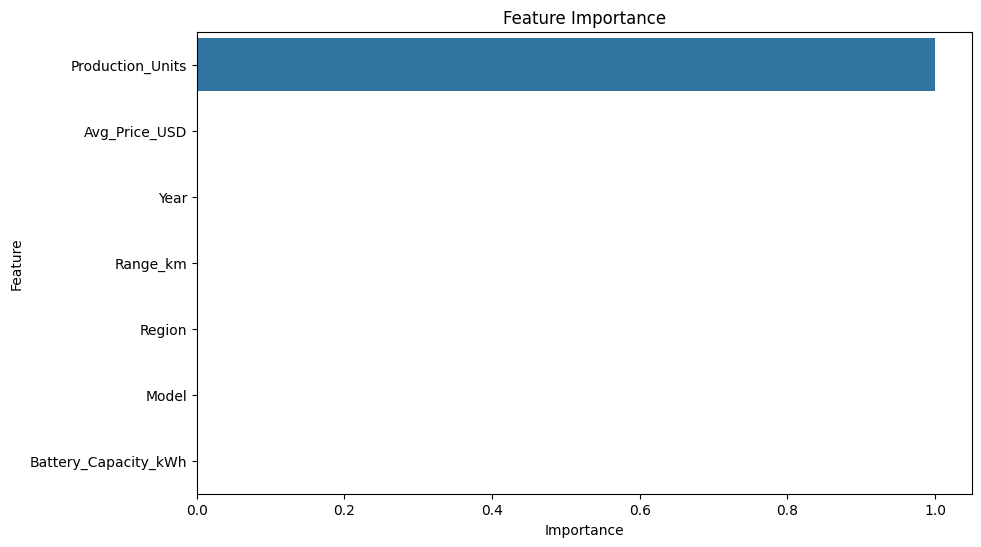

In [90]:
importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

# TIME SERIES FORECASTING

In [91]:

ts_data = df['Estimated_Deliveries']

In [92]:
model = ARIMA(ts_data, order=(1,1,1))

result = model.fit()

In [97]:
# FORECAST FUTURE DELIVERIES
forecast = result.forecast(steps=12)

print("NEXT 12 FORECASTED VALUES")

print(forecast)

NEXT 12 FORECASTED VALUES
2640    10259.138103
2641     9903.046339
2642     9919.686634
2643     9918.909027
2644     9918.945364
2645     9918.943666
2646     9918.943746
2647     9918.943742
2648     9918.943742
2649     9918.943742
2650     9918.943742
2651     9918.943742
Name: predicted_mean, dtype: float64


# PLOT FOREST

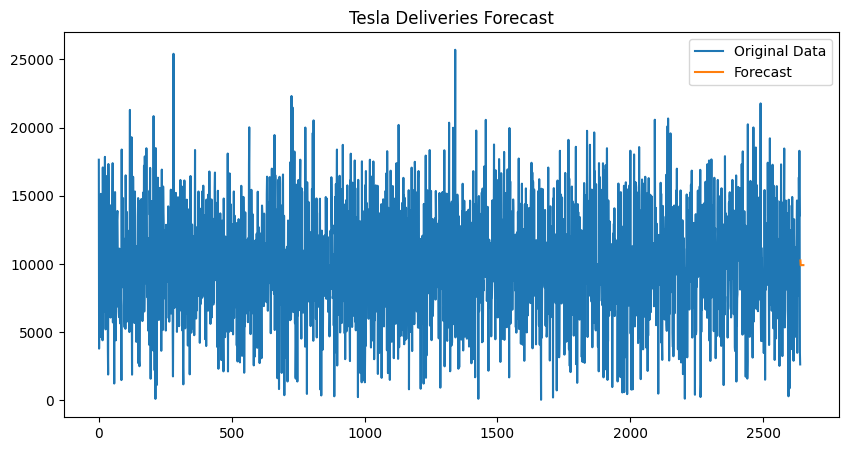

In [94]:
plt.figure(figsize=(10,5))

plt.plot(ts_data,
         label='Original Data')

plt.plot(
    range(len(ts_data),
    len(ts_data)+12),
    forecast,
    label='Forecast'
)

plt.legend()

plt.title("Tesla Deliveries Forecast")

plt.show()

# COMPARE ALL THE MODELS

In [95]:
results = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'R2 Score': [

        r2_score(y_test, linear_pred),

        r2_score(y_test, dt_pred),

        r2_score(y_test, rf_pred)
    ]
})

print(results)

               Model  R2 Score
0  Linear Regression  0.988319
1      Decision Tree  0.972122
2      Random Forest  0.985532


368.3549474512659


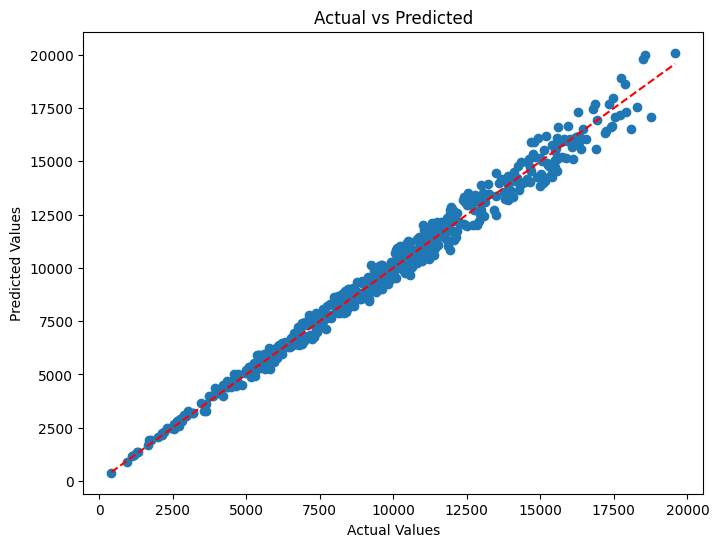

In [102]:
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(y_test, rf_pred))

# graph
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

plt.show()